# Higher-order (p=2) finite element methods in one dimension
Tested on a diffusion problem

We solve
$$
u'' + 50e^x = 0, \qquad x \in [-1,1],
$$
with boundary conditions
$$
u(-1)=100, \qquad u(1)=100.
$$

We use:
- quadratic finite elements,
- Gaussian quadrature for the forcing term,
- direct solution of the assembled linear system.

In [1]:
using LinearAlgebra
using Plots

### Problem setup and quadrature rule

In [53]:
# Number of Gauss points
Nq = 3

# Gauss quadrature points and weights on [-1,1]
xiq, aq = if Nq == 3
    ([-sqrt(3/5), 0.0, sqrt(3/5)],
     [5/9, 8/9, 5/9])
elseif Nq == 2
    ([-1/sqrt(3), 1/sqrt(3)],
     [1.0, 1.0])
else
    ([0.0], [2.0])
end

# Number of elements
nElem = 5

# Element boundary nodes
xn = collect(range(-1.0, 1.0, length=nElem+1))

# Total number of global degrees of freedom for quadratic elements
nDOF = 2*nElem + 1

11

### Local element matrix and basis functions

In [42]:
# Local stiffness matrix on the reference element
Ke = [
    -7/6   4/3  -1/6
     4/3  -8/3   4/3
    -1/6   4/3  -7/6
]

# Quadratic basis functions on the reference element xi in [-1,1]
function phi_quad(xi)
    return [
        -0.5 * xi * (1 - xi),
         (1 - xi) * (1 + xi),
         0.5 * xi * (1 + xi)
    ]
end

# Exact solution
u_exact(x) = -50*exp(x) + 50*x*sinh(1) + 100 + 50*cosh(1);

### Assemble the global stiffness matrix and load vector

In [43]:
# Initialize global stiffness matrix and RHS
K = zeros(nDOF, nDOF)
F = zeros(nDOF)

for elem in 1:nElem
    # Global node numbers for this element
    n = 2*(elem-1) .+ [1, 2, 3]

    xL = xn[elem]
    xR = xn[elem+1]

    dx    = xR - xL
    dxidx = 2 / dx
    dxdxi = dx / 2

    # Stiffness matrix contribution
    K[n, n] .+= dxidx * Ke

    # Quadrature for forcing term
    for q in 1:Nq
        xi = xiq[q]
        w  = aq[q]

        phi = phi_quad(xi)

        # Map xi to physical coordinate x
        x = 0.5*(1 - xi)*xL + 0.5*(1 + xi)*xR

        # Source term from the original script
        f = -50 * exp(x)

        # Element load contribution
        g = phi .* f .* dxdxi

        F[n] .+= w .* g
    end
end

### Apply Dirichlet boundary conditions

In [44]:
# Left boundary: u(-1) = 100
left_node = 1
K[left_node, :] .= 0.0
K[left_node, left_node] = 1.0
F[left_node] = 100.0

# Right boundary: u(1) = 100
right_node = nDOF
K[right_node, :] .= 0.0
K[right_node, right_node] = 1.0
F[right_node] = 100.0;

### Solve for the nodal values

In [45]:
T = K \ F
T

21-element Vector{Float64}:
 100.00000000000001
 103.94151200336428
 107.67953579036563
 111.19274549406077
 114.45741412903716
 117.44749422259007
 120.13400556929379
 122.48513371414371
 124.46548215430084
 126.03619262667317
 127.15403174506389
 127.77153791975512
 127.8359057736015
 127.28916559001492
 126.06682073570434
 124.09806683893922
 121.30412753392592
 117.59852216574302
 112.88503306393226
 107.05803251804504
 100.0

## Sample the FEM solution inside each element for plotting

Because the approximation is quadratic on each element, we evaluate the solution at several points per element to see the curved profile.

In [46]:
Nplot = 20

xp = Float64[]
Tp = Float64[]
up = Float64[]

for elem in 1:nElem
    n = 2*(elem-1) .+ [1, 2, 3]

    xL = xn[elem]
    xR = xn[elem+1]

    Te = T[n]

    for nn in 1:Nplot
        xi = -1 + 2*(nn-1)/(Nplot-1)

        phi = phi_quad(xi)

        x = 0.5*(1 - xi)*xL + 0.5*(1 + xi)*xR
        uh = dot(Te, phi)

        push!(xp, x)
        push!(Tp, uh)
        push!(up, u_exact(x))
    end
end

## Plot FEM solution and exact solution

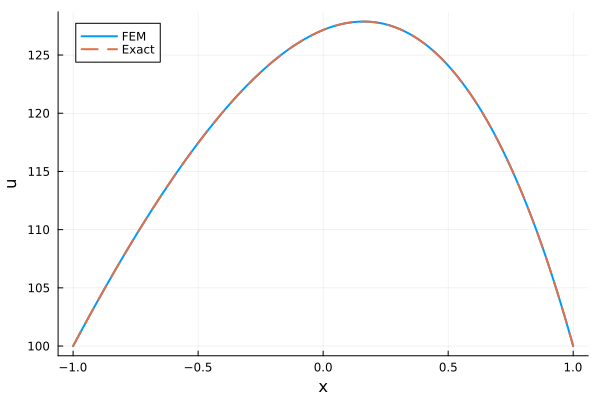

In [47]:
plot(xp, Tp,
    lw = 2,
    label = "FEM",
    xlabel = "x",
    ylabel = "u",
    grid = true)

plot!(xp, up,
    lw = 2,
    ls = :dash,
    label = "Exact")

### Plot the error

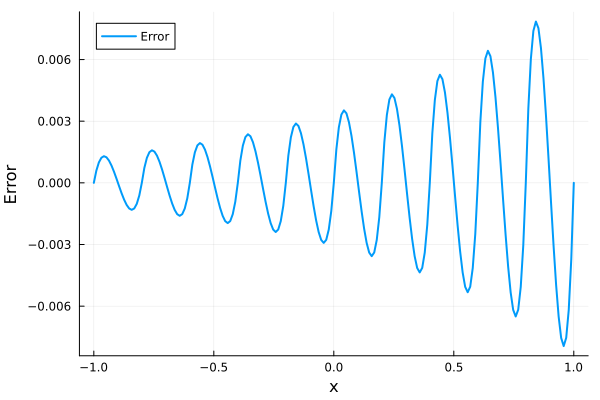

In [48]:
err = Tp .- up

plot(xp, err,
    lw = 2,
    label = "Error",
    xlabel = "x",
    ylabel = "Error",
    grid = true)

In [49]:
println("Maximum error = ", maximum(abs.(err)))

Maximum error = 0.007940368738928782


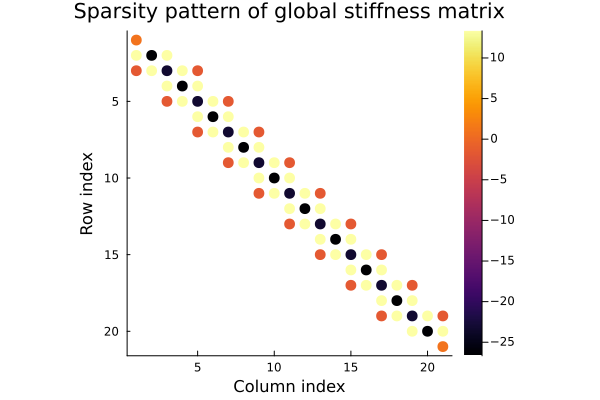

In [50]:
using SparseArrays
using Plots

spy(sparse(K),
    c = :black,
    markerstrokecolor = :black,
    markersize = 6,
    xlabel = "Column index",
    ylabel = "Row index",
    title = "Sparsity pattern of global stiffness matrix")

In [52]:
0.05792373915117821 / 0.007940368738928782

7.294842475916625